# <a id='toc1_'></a>[UMAP: Visão Geral](#toc0_)

##  [Sumário](#toc0_)<a id='toc0_'></a>    
- [UMAP: Visão Geral](#toc1_)    
  - [](#toc1_1_)    
  - [Introdução](#toc1_2_)    
  - [O que é UMAP?](#toc1_3_)    
    - [Redução de Dimensionalidade](#toc1_3_1_)    
    - [Abordagens existentes](#toc1_3_2_)    
    - [Como funciona o UMAP?](#toc1_3_3_)    
  - [Exemplo prático](#toc1_4_)    
    - [Hiperparâmetros](#toc1_4_1_)    
      - [n_neighbors](#toc1_4_1_1_)    
      - [min_dist](#toc1_4_1_2_)    
  - [Conclusões e possíveis aplicações](#toc1_5_)    
  - [Materiais Complementares](#toc1_6_)    
      - [1. Vídeo introdutório - Statquest  ](#toc1_6_1_1_)    
      - [2. Palestra de um dos autores originais explicando o algoritmo  ](#toc1_6_1_2_)    
      - [3. Artigo Original  ](#toc1_6_1_3_)    
      - [4. Visualizações interessantes  ](#toc1_6_1_4_)    
  - [Referências](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Introdução](#toc0_)

O objetivo principal desse notebook é apresentar ao leitor uma visão geral do método de **UMAP** (_Uniform Manifold Approximation and Projection_) sem se aprofundar em todos os detalhes matemáticos que permeiam a técnica. (Caso queira entender mais sobre esses detalhes, confira o notebook [01 - UMAP Detalhado](01%20-%20UMAP%20Detalhado.ipynb)). O intuito é propor ao leitor um entendimento abrangente do conceito através de uma breve explicação, possíveis aplicações, e uma lista de materiais complementares.

---

## <a id='toc1_3_'></a>[O que é UMAP?](#toc0_)

O termo **UMAP** significa _Uniform Manifold Approximation and Projection_ (Aproximação e Projeção Uniforme de Manifolds) e designa uma técnica de redução de dimensionalidade com uma eficiência computacional elevada baseada em geometria Riemanniana e topologia algébrica. Para entendermos como o UMAP funciona e como podemos aplicá-lo, precisamos primeiramente entender o problema que ele se propõe a resolver: a **redução de dimensionalidade**.

### <a id='toc1_3_1_'></a>[Redução de Dimensionalidade](#toc0_)

Vamos supor que possuímos um determinado conjunto de dados sobre pessoas, com dois atributos: _altura_ e _peso_. Sabe-se que podemos simplesmente plotar os dados em um gráfico no qual um dos eixos indica a altura e outro o peso, como na [Figura 1](#grafico_peso_altura).

<img src="../assets/grafico_peso_altura.png" width=300px id="grafico_peso_altura"> <br/>
**Figura 1:** Gráfico ilustrativo com eixos _peso_ e _altura_. <br/>
<small>Fonte: Autoria própria</small>

A partir do gráfico, conseguimos visualizar os dados e entendê-los de uma forma mais adequada. Por exemplo, nesse gráfico é possível distinguir dois grupos de dados que provavelmente indicam pessoas semelhantes, além de alguns pontos que se distanciam dos outros grupos, indicando possíveis anomalias, como mostra a [Figura 2](#grafico_peso_altura_clusters)

<img src="../assets/grafico_peso_altura_clusters.png" width=300px id="grafico_peso_altura_clusters"> <br/>
**Figura 2:** Gráfico ilustrativo com eixos _peso_ e _altura_. Grupos semelhantes de dados estão com a mesma cor (azul e vermelho). Os pontos em verde representam valores discrepantes. <br/>
<small>Fonte: Autoria própria</small>

Se nosso conjunto de dados possuisse mais um atributo, idade, por exemplo, então precisaríamos de um gráfico tridimensional para visualizar a distribuição dos dados, o que já pode dificultar um pouco a interpretação, mas ainda é possível.

<img src="../assets/grafico_peso_altura_idade.png" width=300px id="grafico_peso_altura_idade"> <br/>
**Figura 3:** Gráfico ilustrativo com eixos _peso_, _altura_ e _idade_. Grupos semelhantes de dados estão com a mesma cor (azul e vermelho). Os pontos em verde representam valores discrepantes. <br/>
<small>Fonte: Autoria própria</small>

Mas quando esse conjunto começa a ter 4, 10, ou até mesmo centenas de atributos distintos, a visualização clara de agrupamentos por uma simples plotagem se torna inviável.

É justamente nesse contexto que entra a **redução de dimensionalidade**. O objetivo aqui é tentar projetar o conjunto de dados em um número menor de dimensões, sem perder as relações de vizinhança e estrutura, para conseguir visualizá-los e interpretá-los melhor. A redução de dimensionalidade também pode ser útil para pré-processamento de dados ao induzir um modelo de machine learning, por exemplo, principalmente se existem muitos atributos redundantes ou talvez ruidosos.

### <a id='toc1_3_2_'></a>[Abordagens existentes](#toc0_)

Para resolver esse problema, diversas abordagens surgiram ao longo do tempo, cada uma com suas vantagens e desvantagens. Vamos pensar em um conjunto bidimensional qualquer, com atributos _X_ e _Y_:

<img src="../assets/grafico_x_y.png" width=300px id="grafico_x_y"> <br/>
**Figura 4:** Gráfico ilustrativo com eixos _X_ e _Y_.<br/>
<small>Fonte: Autoria própria</small>

Novamente, conseguimos observar 3 agrupamentos (ou _clusters_) de dados:

<img src="../assets/grafico_x_y_clusters.png" width=300px id="grafico_x_y_clusters"> <br/>
**Figura 5:** Gráfico ilustrativo com eixos _X_ e _Y_. As cores representam os agrupamentos de dados semelhantes<br/>
<small>Fonte: Autoria própria</small>

Nosso objetivo aqui será reduzir a dimensionalidade desses dados para uma única linha.

Um método trivial que poderíamos utilizar para fazer isso, seria apenas projetar os dados em um dos eixos, mas note que isso não resolve nosso problema, pois observações distintas ficam próximas e as relações de vizinhanças não são mantidas.

<img src="../assets/grafico_x_y_projecao.png" width=300px id="grafico_x_y_projecao"> <br/>
**Figura 6:** Gráfico ilustrativo com eixos _X_ e _Y_. As cores representam os agrupamentos de dados semelhantes. Os dados estão sendo projetados em direção ao eixo _X_, criando um novo conjunto com dimensão reduzida<br/>
<small>Fonte: Autoria própria</small>

Então precisamos encontrar uma forma de reduzir a dimensionalidade sem perder essas relações, e para isso foram criadas diferentes estratégias. Algumas focam em preservar a estrutura de distância global das amostras, como o _PCA_, o _MDS_, ou o _Sammon mapping_, enquanto outras favorecem a preservação de estruturas locais, como o _t-SNE_, o _Isomap_, o _LargeVis_, a _imersão Laplaciana_ ou _mapas de difusão_. [[3](#referencias)]

Cada uma dessas estratégias possui suas vantagens e desvantagens, podendo ser uma alternativa adequada dependendo do conjunto de dados e da disponibilidade de tempo e de computação. O _UMAP_ surge justamente como uma tentativa de unir o melhor dos mundos, apresentando-se como um algoritmo que tenta preservar as relações locais sem perder muitas informações da estrutura global, além de apresentar um desempenho computacional superior ao de algoritmos frequentemente utilizados, como o _t-SNE_, o qual era considerado por muitos como o estado da arte na questão de redução de dimensionalidade.

Caso queira entender mais sobre o funcionamento de alguns algoritmos específicos, recomendo a referência [[4](#referencias)] para conhecer a técnica de _PCA_ e a referência [[5](#referencias)] para entender a lógica simplificada do _t-SNE_.

### <a id='toc1_3_3_'></a>[Como funciona o UMAP?](#toc0_)

Então agora, sem mais delongas, podemos finalmente explicar como é o funcionamento real do _UMAP_. Todas as decisões tomadas durante a construção do algoritmo possuem uma base matemática sólida e justificações lógicas, porém não entraremos nesses detalhes por enquanto. Apesar do detalhamento algébrico, é fácil entender de forma intuitiva o mecanismo essencial da técnica.

Essencialmente, o funcionamento do UMAP se assemelha muito ao do t-SNE, construindo uma representação topológica hiperdimensional dos dados e otimizando uma representação equivalente em um espaço de baixa dimensão para aproximá-la da estrutura original. O real poder do UMAP está na forma como ele cria a representação topológica hiperdimensional.

Primeiramente, ele constrói uma estrutura conhecida como _complexo simplicial fuzzy_, a qual pode ser entendida como a representação de um grafo ponderado no qual cada aresta indica o grau de pertencimento entre dois pontos.

Entretanto, temos um problema: como escolher o tamanho dos raios? Se escolhermos um raio fixo, regiões densas vão ter muitas conexões enquanto regiões mais esparsas poderiam ter pontos sem conexão nenhuma, mas para aplicar as teorias algébricas necessárias precisamos de um conjunto uniforme.

Como praticamente nenhum conjunto de dados real é tão uniforme assim, o UMAP toma outra decisão: os raios são escolhidos localmente, com base na distância até o _n_ vizinho mais próximo. Outra adição do UMAP é escolher um raio difuso, o qual diminui a força de acordo com a distância.

Por último, precisamos que o manifold seja localmente conectado, então cada ponto é conectado pelo menos com seu vizinho mais próximo, sem deixar nenhum dado isolado.

O código a seguir monta um gráfico interativo que ilustra a construção do complexo, inspirado nas referências [[6](#referencias)] e [[7](#referencias)].

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from ipywidgets import interact, IntSlider, FloatSlider
import numpy as np

%matplotlib inline

In [2]:
# Monta um conjunto sintético de dados
x = np.array([i + np.random.uniform(-0.01,0.01) for i in np.linspace(0, np.pi * 4, 100)])
x = np.delete(x, np.random.randint(0, len(x), 80))

y = np.array([i + np.random.normal(-0.1,0.1) for i in np.sin(x+np.random.uniform(-40,40))]) * 3
data = np.array([[x[i], y[i]] for i in range(len(x))])

cmap = plt.get_cmap("viridis")
norm = Normalize(0, len(data))

def plot_fuzzy_construction(n_neighbors=5):
    plt.figure(figsize=(10, 7))
    
    # Busca os n vizinhos mais próximos
    def calculate_normal_factor(min_dists, n_neighbors):
        min_interval = 0.001
        max_interval = 1
        
        min_sigma = min_interval
        max_sigma = max_interval
        
        sigma = min_sigma + (max_sigma - min_sigma) / 2
        calculated = np.sum(np.exp(-(min_dists - min_dists[0])/sigma))
        
        expected = np.log2(n_neighbors)
        
        while abs(calculated - expected) > 1e-6:
            # print(f"min_sigma: {min_sigma:.4f} | max_sigma: {max_sigma:.4f} | tentando sigma {sigma:.4f} | Calculado: {calculated} | Esperado: {expected}")
            
            if sigma == max_interval:
                max_interval *= 2
                max_sigma = max_interval
            elif sigma == min_interval:
                min_interval /= 2
                min_sigma = min_interval
            
            if calculated > expected:
                max_sigma = sigma
            else:
                min_sigma = sigma
                
            sigma = min_sigma + (max_sigma - min_sigma) / 2
            calculated = np.sum(np.exp(-(min_dists - min_dists[0])/sigma))
        
        return sigma
                
    nearest_neighbor_dists = []
    nearest_neighbors_index = []
    normal_factors = []

    for i, p in enumerate(data):
        min_dists = np.full(n_neighbors, float("inf"))
        nearest_neighbors = np.full(n_neighbors, -1)
            
        for j, p2 in enumerate(data):
            if j == i: continue
            
            dist = np.sqrt((p[0]-p2[0])**2 + (p[1]-p2[1])**2)
            
            for k in range(n_neighbors):
                if dist < min_dists[k]:
                    min_dists = np.insert(min_dists, k, dist)
                    min_dists = np.delete(min_dists, len(min_dists)-1)
                    nearest_neighbors = np.insert(nearest_neighbors, k, j)
                    nearest_neighbors = np.delete(nearest_neighbors, len(nearest_neighbors)-1)
                    break
        
        # print(*min_dists)
        nearest_neighbor_dists.append(min_dists)
        nearest_neighbors_index.append(nearest_neighbors)
        normal_factors.append(calculate_normal_factor(min_dists, n_neighbors))
        
    # Plota o gráfico    
    def plot_fuzzy_spot(x, y, rho, sigma, color, resolution=100, size=4, img_alpha= 0.8):
        size = rho + size * sigma

        grid = np.linspace(-size, size, resolution)
        X, Y = np.meshgrid(grid, grid)

        dist = np.sqrt(X**2 + Y**2)

        alpha = np.exp(-np.maximum(0, dist - rho) / sigma)
        
        rgba = np.zeros((resolution, resolution, 4))
        rgba[:, :, :3] = color[:3]
        rgba[:, :, 3] = alpha

        plt.imshow(
            rgba,
            extent=(
                x - size, x + size,
                y - size, y + size
            ),
            origin="lower",
            alpha=img_alpha
        )
        
    
    for i, r in enumerate(nearest_neighbor_dists):
        color = cmap(norm(i))
        
        circle = Circle((x[i], y[i]), r[0], color=color, alpha=0.2, linewidth=0)
        plt.gca().add_patch(circle)
        
        plot_fuzzy_spot(x[i], y[i], r[0], normal_factors[i], color=color, img_alpha=0.3)
        
        for j, dist in zip(nearest_neighbors_index[i], r):
            prob = np.exp(-max(0, dist - r[0])/normal_factors[i])
            line = Line2D([x[i], x[j]], [y[i], y[j]], color=color, linewidth=prob*2, alpha=min(1, prob*1.5))
            plt.gca().add_line(line)
            
        circle = Circle((x[i], y[i]), 0.1, color=color, alpha=1, linewidth=0)
        plt.gca().add_patch(circle)
        
    plt.ylim(-5, 5)
    plt.xlim(-1, 14)
    plt.gca().set_aspect("equal")
    plt.show()
    
interact(
    plot_fuzzy_construction,
    n_neighbors=IntSlider(min=2, max=20, step=1, value=5) 
);


interactive(children=(IntSlider(value=5, description='n_neighbors', max=20, min=2), Output()), _dom_classes=('…

Com a estrutura topológica hiperdimensional definida, o próximo passo do algoritmo é otimizar uma estrutura de dimensão menor. Para isso, ele inicializa uma representação de baixa dimensão e compara a entropia cruzada entre ele e a topologia hiperdimensional. A partir dessa diferença, o UMAP vai atualizando sucessivamente as posições dos pontos de modo a diminuir essa entropia e aumentar a similaridade das estruturas. De uma forma intuitiva, isso pode ser entendido como relações mais fortes atuando com forças de atração enquanto relações mais fracas (ou inexistentes) repelem os dados.

A partir desse processo, a nova representação apresenta uma semelhança estrutural, global mas principalmente local, com o complexo simplicial fuzzy montado para os dados hiperdimensionais, proporcionando uma forma melhor de visualizar ou analisar determinado conjunto.

## <a id='toc1_4_'></a>[Exemplo prático](#toc0_)

Agora mostrarei como aplicar de maneira prática o algoritmo do UMAP em um conjunto de dados escolhido. Nesse caso, vamos utilizar o dataset *penguins* importado do módulo *seaborn*. Para implementar o algoritmo, utilizaremos a biblioteca _umap-learn_. Caso não tenha essa biblioteca instalada em seu ambiente, certifique-se de rodar o bloco de código a seguir e reiniciar o kernel:

In [3]:
%pip install umap-learn -q

Note: you may need to restart the kernel to use updated packages.


Uma vez com as dependências instaladas, podemos escrever o código. Primeiramente, vamos importar a base de dados e realizar um tratamento inicial, removendo linhas com valores vazios.

*Nota:* para uma aplicação real, é recomendado ter mais cautela com tratamentos desse tipo. Nesse caso, como utilizaremos o dataset apenas como exemplo didático, não tem problema apagar essas observações.

In [4]:
import seaborn as sns

In [5]:
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna(axis=0)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


A partir de um conjunto como esse, podemos querer analisar como diferentes espécies se relacionam com diferentes características. Por exemplo, como o comprimento do bico e da nadadeira estão relacionados com a espécie? Podemos observar isso de forma simples através de um gráfico com eixos *bill_length_mm* e *flipper_length_mm* no qual cada espécie está representada com uma cor.

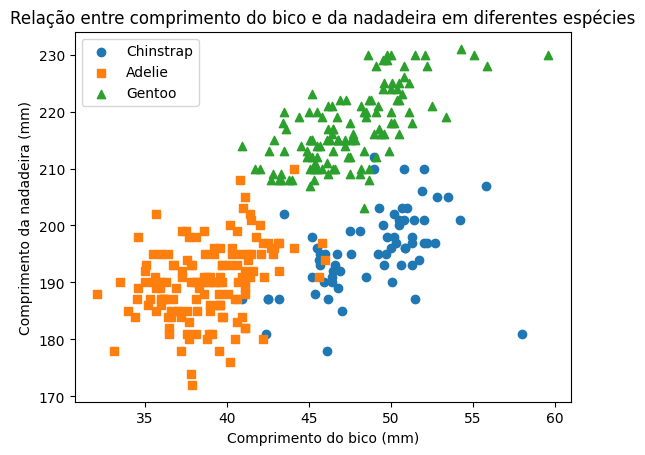

In [6]:
for specie, marker in zip(set(penguins["species"]), ["o", "s", "^"]):
    plt.scatter(
        penguins["bill_length_mm"][penguins["species"] == specie].values,
        penguins["flipper_length_mm"][penguins["species"] == specie].values,
        label=specie,
        marker=marker
    )

plt.title("Relação entre comprimento do bico e da nadadeira em diferentes espécies")
plt.xlabel("Comprimento do bico (mm)")
plt.ylabel("Comprimento da nadadeira (mm)")
plt.legend()
plt.show()

É possível observar que já existe uma certa separação. Se incluirmos a massa do pinguim, será que ficaria ainda mais evidente? Podemos tentar observar isso com um plot 3D:

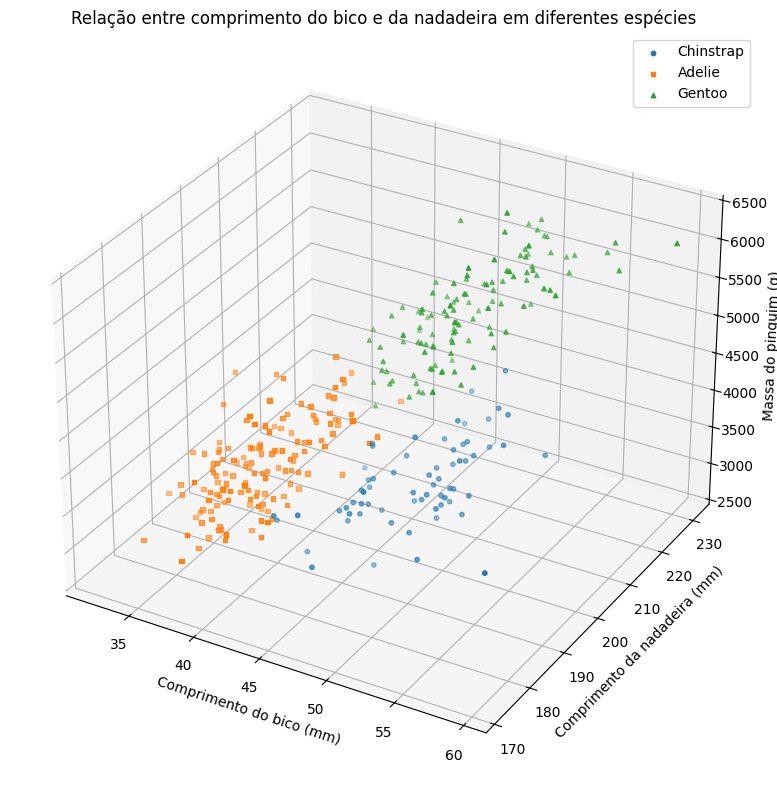

In [7]:
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection="3d")

for specie, marker in zip(set(penguins["species"]), ["o", "s", "^"]):

    ax.scatter(
        xs=penguins["bill_length_mm"][penguins["species"] == specie].values,
        ys=penguins["flipper_length_mm"][penguins["species"] == specie].values,
        zs=penguins["body_mass_g"][penguins["species"] == specie].values,
        label=specie,
        marker=marker,
        s=10
    )

ax.set_title("Relação entre comprimento do bico e da nadadeira em diferentes espécies")

ax.set_xlabel("Comprimento do bico (mm)")
ax.set_ylabel("Comprimento da nadadeira (mm)")
ax.set_zlabel("Massa do pinguim (g)")

ax.legend()
fig.tight_layout()

plt.show()

Mas e se quisermos comparar com um quarto atributo? E um quinto? Ou centenas, quem sabe milhares de atributos. Isso já não seria mais possível com uma simples visualização, e é aí que entra o **UMAP**. Para utilizá-lo, vamos primeiro instanciar um objeto UMAP que será responsável por realizar o trabalho pesado para nós.

In [8]:
import umap
from sklearn.preprocessing import StandardScaler

In [9]:
reducer = umap.UMAP()

Vamos implementar o UMAP com 4 atributos do nosso dataset: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` e `body_mass_g`. Como eles estão em escalas completamente diferentes, podemos utilizar o método `StandardScaler` do módulo *sklearn* para aplicar a normalização padrão aos dados (deixando todos em uma escala com média igual a zero e desvio padrão igual a 1).

In [10]:
penguin_data = penguins.reindex([
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
], axis=1)

scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

Uma vez com os dados tratados, podemos usar o método `fit` do reducer criado para montar o grafo que representa nosso conjunto de dados hiperdimensional. Então, o método `transform` será aplicado para redimensionar os dados novamente para uma estrutura de baixa dimensão (2 por padrão)

In [11]:
# Nesse caso também poderíamos utilizar o fit_transform para as duas operações de uma vez no mesmo dataset:
# embeddings = reducer.fit_transform(scaled_penguin_data)

reducer.fit(scaled_penguin_data)

embeddings = reducer.transform(scaled_penguin_data)
embeddings.shape

(333, 2)

Como podemos observar, a dimensão dos dados transformados é de apenas 2 atributos para cada observação do conjunto original (o número de dimensões da representação aproximada pode ser definido a partir do hiperparâmetro `n_components` ao instanciar o objeto UMAP), e não os 4 atributos que utilizamos de entrada. Assim, podemos facilmente visualizar o resultado em um gráfico bidimensional, colorindo os pontos de acordo com a espécie para facilitar a identificação.

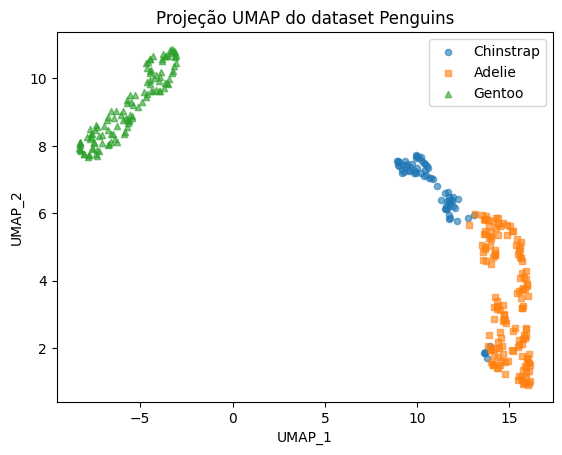

In [12]:
for specie, marker in zip(set(penguins["species"]), ["o", "s", "^"]):
    plt.scatter(
        embeddings[:, 0][penguins["species"] == specie],
        embeddings[:, 1][penguins["species"] == specie],
        label=specie,
        marker=marker,
        alpha=0.6,
        s=20
    )

plt.title("Projeção UMAP do dataset Penguins")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend()
plt.show()

É possível observar que, mesmo sem passar essa informação para o UMAP, as espécies foram agrupadas por conta das semelhanças das medidas entre seus indivíduos. Não somente isso, mas também percebemos como os pinguins da espécie _Gentoo_ se diferem mais das outras espécies, e isso faz sentido quando observamos as três espécies lado a lado:

<img src="../assets/penguins_comparison.jpg"> <br/>
**Figura 7:** Comparação entre três espécies de pinguins: Adelie, Gentoo e Chinstrap<br/>
<small>Fonte: PET Estatística UFC (RPubs).[<a href="#referencias">12</a>]</small>

### <a id='toc1_4_1_'></a>[Hiperparâmetros](#toc0_)

Ao criarmos o reducer do UMAP, podemos passar alguns hiperparâmetros a depender da aplicação. A seguir explicarei sobre os principais hiperparâmetros que podemos modificar além de proporcionar uma visualização interativa de como cada um interfere no resultado final.

#### <a id='toc1_4_1_1_'></a>[n_neighbors](#toc0_)
*Valor padrão*: 15
Tamanho da vizinhança local considerada para a aproximação dos manifolds. Valores maiores tendem a resultar em visões mais globais, enquanto valores menores preservam melhor estruturas locais. Geralmente varia de 2 a 100.

#### <a id='toc1_4_1_2_'></a>[min_dist](#toc0_)
*Valor padrão*: 0.1
Determina a distância mínima efetiva entre pontos conectados. Valores menores resultam em uma visualização mais agrupada enquanto valores maiores espalham mais os dados.

In [ ]:
def plot_penguins_UMAP(n_neighbors, min_dist):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    
    embeddings = reducer.fit_transform(scaled_penguin_data)
    
    for specie, marker in zip(set(penguins["species"]), ["o", "s", "^"]):
        plt.scatter(
            embeddings[:, 0][penguins["species"] == specie],
            embeddings[:, 1][penguins["species"] == specie],
            label=specie,
            marker=marker,
            alpha=0.6,
            s=20
        )

    plt.title("Projeção UMAP do dataset Penguins")
    plt.xlabel("UMAP_1")
    plt.ylabel("UMAP_2")
    plt.legend()
    plt.show()
    
interact(plot_penguins_UMAP,
    n_neighbors=IntSlider(min=2, max=100, step=1, value=15),
    min_dist=FloatSlider(min=0.01, max=1, step=0.01, value=0.1)
);

interactive(children=(IntSlider(value=15, description='n_neighbors', min=2), FloatSlider(value=0.1, descriptio…

## <a id='toc1_5_'></a>[Conclusões e possíveis aplicações](#toc0_)

Como podemos ver, o algoritmo de UMAP é extremamente eficiente para visualizar grandes conjuntos de dados com muitos atributos. Isso confere ao método uma usabilidade enorme para aplicações de análise de dados em diferentes áreas, desde a bioinformática até o aprendizado de máquinas, conferindo um entendimento melhor das informações através da redução de dimensionalidade.

Os fundamentos matemáticos do algoritmo permitem que estruturas de vizinhança locais e, em determinadas situações, aspectos da estrutura global possam ser preservados mesmo em baixas dimensões. Entretanto, vale ressaltar que qualquer método de redução de dimensões irá perder informações do conjunto de dados original, e nunca poderemos projetar perfeitamente um conjunto hiperdimensional em um plano de baixa dimensão.

## <a id='toc1_6_'></a>[Materiais Complementares](#toc0_)

Aqui deixarei uma lista de materiais complementares que me auxiliaram a entender melhor o funcionamento do algoritmo e podem ser interessantes para leitores curiosos.

#### <a id='toc1_6_1_1_'></a>[1. Vídeo introdutório - Statquest](https://www.youtube.com/watch?v=eN0wFzBA4Sc)   [&#8593;](#toc0_)
<img src="../assets/statquest-1-thumbnail.jpg" width="500"><br/>
Esse vídeo introdutório explica os conceitos gerais do UMAP de forma expositiva, sem adentrar nos detalhes matemáticos.

#### <a id='toc1_6_1_2_'></a>[2. Palestra de um dos autores originais explicando o algoritmo](https://www.youtube.com/watch?v=nq6iPZVUxZU)   [&#8593;](#toc0_)
<img src="../assets/umap-explanation.jpg" width="500"><br/>
Nessa fala, Leland McInnes, um dos autores do artigo original, explica de forma intuitiva e elegante as ideias por trás do algoritmo pensado para a redução eficiente de dimensionalidade.

#### <a id='toc1_6_1_3_'></a>[3. Artigo Original](https://arxiv.org/abs/1802.03426)   [&#8593;](#toc0_)
<img src="../assets/umap-paper.png" width="500"><br/>
Artigo original do UMAP com explicações detalhadas dos fundamentos matemáticos e de possíveis aplicações.

#### <a id='toc1_6_1_4_'></a>[4. Visualizações interessantes](https://umap-learn.readthedocs.io/en/latest/interactive_viz.html)   [&#8593;](#toc0_)
<img src="../assets/UMAP-logo.webp" width="500"><br/>
Lista de diversas visualizações interativas para compreender melhor o funcionamento do algoritmo.

<span id="referencias"></span>
## <a id='toc1_7_'></a>[Referências](#toc0_)

1. **STATQUEST WITH JOSH STARMER.** *UMAP: Main Ideas!!!*. YouTube, 2023. Disponível em: <https://www.youtube.com/watch?v=eN0wFzBA4Sc>. Acesso em: 9 set. 2026.

2. **STATQUEST WITH JOSH STARMER.** *UMAP: Mathematical Details*. YouTube, 2023. Disponível em: <https://www.youtube.com/watch?v=jth4kEvJ3P8>. Acesso em: 9 set. 2026.

3. **MCINNES, Leland; HEALY, John; MELVILLE, James.** *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv, 2018. Disponível em: <https://arxiv.org/abs/1802.03426>. Acesso em: 9 set. 2026.

4. **STATQUEST WITH JOSH STARMER.** *StatQuest: Principal Component Analysis (PCA), Step-by-Step*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=FgakZw6K1QQ>. Acesso em: 9 set. 2026.

5. **STATQUEST WITH JOSH STARMER.** *StatQuest: t-SNE clearly explained*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=NEaUSP4YerM>. Acesso em: 9 set. 2026.

6. **COENEN, Andy; PEARCE, Adam.** *Understanding UMAP*. Google PAIR, [s. d.]. Disponível em: <https://pair-code.github.io/understanding-umap/>. Acesso em: 11 set. 2026.

7. **MCINNES, Leland.** *UMAP: Uniform Manifold Approximation and Projection for Dimensional Reduction*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=nq6iPZVUxZU>. Acesso em: 11 set. 2026.

8. **NUMPY DEVELOPERS.** *NumPy documentation*. [S. l.], 2026. Disponível em: <https://numpy.org/doc/stable/index.html>. Acesso em: 11 set. 2026.

9. **MATPLOTLIB DEVELOPMENT TEAM.** *Matplotlib 3.11.1 documentation*. [S. l.], 2026. Disponível em: <https://matplotlib.org/stable/>. Acesso em: 11 set. 2026.

10. **SEABORN DEVELOPERS.** *seaborn: statistical data visualization*. [S. l.]: Seaborn, [s. d.]. Disponível em: <https://seaborn.pydata.org/>. Acesso em: 18 set. 2026.

11. **PANDAS DEVELOPERS.** *pandas documentation*. [S. l.]: pandas, 2026. Disponível em: <https://pandas.pydata.org/docs/reference/index.html>. Acesso em: 18 set. 2026.

12. **PET ESTATÍSTICA UFC.** *Documento para o minicurso de RMarkdown*. RPubs, [s. d.]. Disponível em: <https://rpubs.com/pet_estatisticaufc/1261808>. Acesso em: 18 set. 2026.